In [273]:
import tensorflow as tf
import os
import filetype
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


In [274]:
data_dir = 'data'
imageTypes = ["jpg", "jpeg", "png", "bmp"]

In [275]:
'''
for data_type in os.listdir(data_dir):
    for image_class in os.listdir(data_dir): 
        for image in os.listdir(os.path.join(data_dir, image_class)):
            image_path = os.path.join(data_dir, image_class, image)
            try: 
                img = cv2.imread(image_path)
                kind = filetype.guess(image_path)
                if kind is None or kind.extension not in imageTypes:
                    print(f'Image {image_path} is of type {kind}. Should be in {imageTypes}')
                    os.remove(image_path)
            except Exception as e: 
                print('Issue with image {}'.format(image_path))
                os.remove(image_path)
'''

"\nfor data_type in os.listdir(data_dir):\n    for image_class in os.listdir(data_dir): \n        for image in os.listdir(os.path.join(data_dir, image_class)):\n            image_path = os.path.join(data_dir, image_class, image)\n            try: \n                img = cv2.imread(image_path)\n                kind = filetype.guess(image_path)\n                if kind is None or kind.extension not in imageTypes:\n                    print(f'Image {image_path} is of type {kind}. Should be in {imageTypes}')\n                    os.remove(image_path)\n            except Exception as e: \n                print('Issue with image {}'.format(image_path))\n                os.remove(image_path)\n"

In [276]:
train_normal_dir = os.path.join(data_dir, 'train/NORMAL')
train_pneu_dir = os.path.join(data_dir, 'train/PNEUMONIA')

test_normal_dir = os.path.join(data_dir, 'test/NORMAL')
test_pneu_dir = os.path.join(data_dir, 'test/PNEUMONIA')

val_normal_dir = os.path.join(data_dir, 'val/NORMAL')
val_pneu_dir = os.path.join(data_dir, 'val/PNEUMONIA')

In [277]:
train_list = []
test_list = []
val_list = []

In [278]:
def get_all_images(directory, imageTypes):
    files = []
    for ext in imageTypes:
        files.extend(glob.glob(os.path.join(directory, f'*.{ext}')))
    return files

train_normal_cases = get_all_images(train_normal_dir, imageTypes)
train_pneu_cases = get_all_images(train_pneu_dir, imageTypes)

test_normal_cases = get_all_images(test_normal_dir, imageTypes)
test_pneu_cases = get_all_images(test_pneu_dir, imageTypes)

val_normal_cases = get_all_images(val_normal_dir, imageTypes)
val_pneu_cases = get_all_images(val_pneu_dir, imageTypes)

In [279]:
train_normal_cases = [x.replace('\\', '/') for x in train_normal_cases]
train_pneu_cases = [x.replace('\\', '/') for x in train_pneu_cases]
test_normal_cases = [x.replace('\\', '/') for x in test_normal_cases]
test_pneu_cases = [x.replace('\\', '/') for x in test_pneu_cases]
val_normal_cases = [x.replace('\\', '/') for x in val_normal_cases]
val_pneu_cases = [x.replace('\\', '/') for x in val_pneu_cases]

In [280]:
for img in train_normal_cases:
    train_list.append([img, 0])
    
for img in train_pneu_cases:
    train_list.append([img, 1])
    
for img in test_normal_cases:
    test_list.append([img, 0])
    
for img in test_pneu_cases:
    test_list.append([img, 1])
    
for img in val_normal_cases:
    val_list.append([img, 0])
    
for img in val_pneu_cases:
    val_list.append([img, 1])

In [281]:
random.shuffle(train_list)

In [282]:
train_df = pd.DataFrame(train_list, columns=['image', 'label'])
test_df = pd.DataFrame(test_list, columns=['image', 'label'])
val_df = pd.DataFrame(val_list, columns=['image', 'label'])

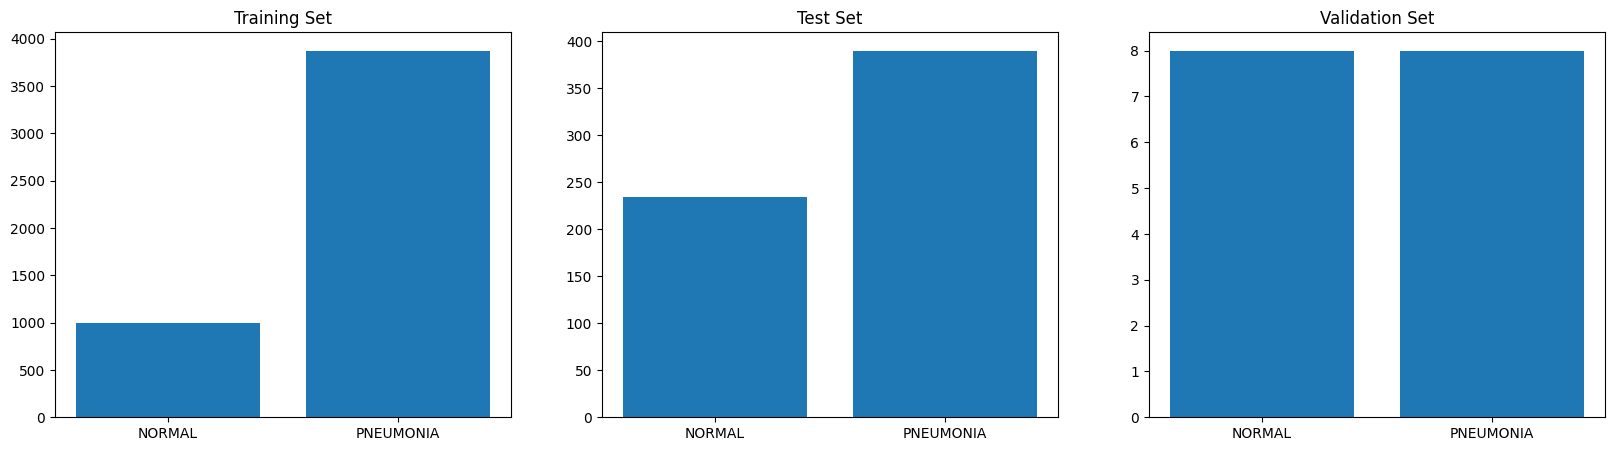

In [283]:
plt.figure(figsize=(20,5))

plt.subplot(1, 3, 1)
labels = ["NORMAL", "PNEUMONIA"]
values = [len(os.listdir(train_normal_dir)), len(os.listdir(train_pneu_dir))]
plt.bar(labels, values)
plt.title("Training Set")

plt.subplot(1, 3, 2)
labels = ["NORMAL", "PNEUMONIA"]
values = [len(os.listdir(test_normal_dir)), len(os.listdir(test_pneu_dir))]
plt.bar(labels, values)
plt.title("Test Set")

plt.subplot(1, 3, 3)
labels = ["NORMAL", "PNEUMONIA"]
values = [len(os.listdir(val_normal_dir)), len(os.listdir(val_pneu_dir))]
plt.bar(labels, values)
plt.title("Validation Set")

plt.show()

In [ ]:
def process_data(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (196, 196))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img/255.0
    img = np.reshape(img, (196,196,1))
    return img

def compose_dataset(df):
    data = []
    labels = []
    for img_path, label in df.values:
        data.append(process_data(img_path))
        labels.append(label)
        
    return np.array(data), np.array(labels)

X_train, y_train = compose_dataset(train_df)
X_test, y_test = compose_dataset(test_df)
X_val, y_val = compose_dataset(val_df)

In [ ]:
print('Train data shape: {}, Labels shape: {}'.format(X_train.shape, y_train.shape))
print('Test data shape: {}, Labels shape: {}'.format(X_test.shape, y_test.shape))
print('Validation data shape: {}, Labels shape: {}'.format(X_val.shape, y_val.shape))


Train data shape: (4875, 196, 196, 1), Labels shape: (4875,)
Test data shape: (624, 196, 196, 1), Labels shape: (624,)
Validation data shape: (16, 196, 196, 1), Labels shape: (16,)


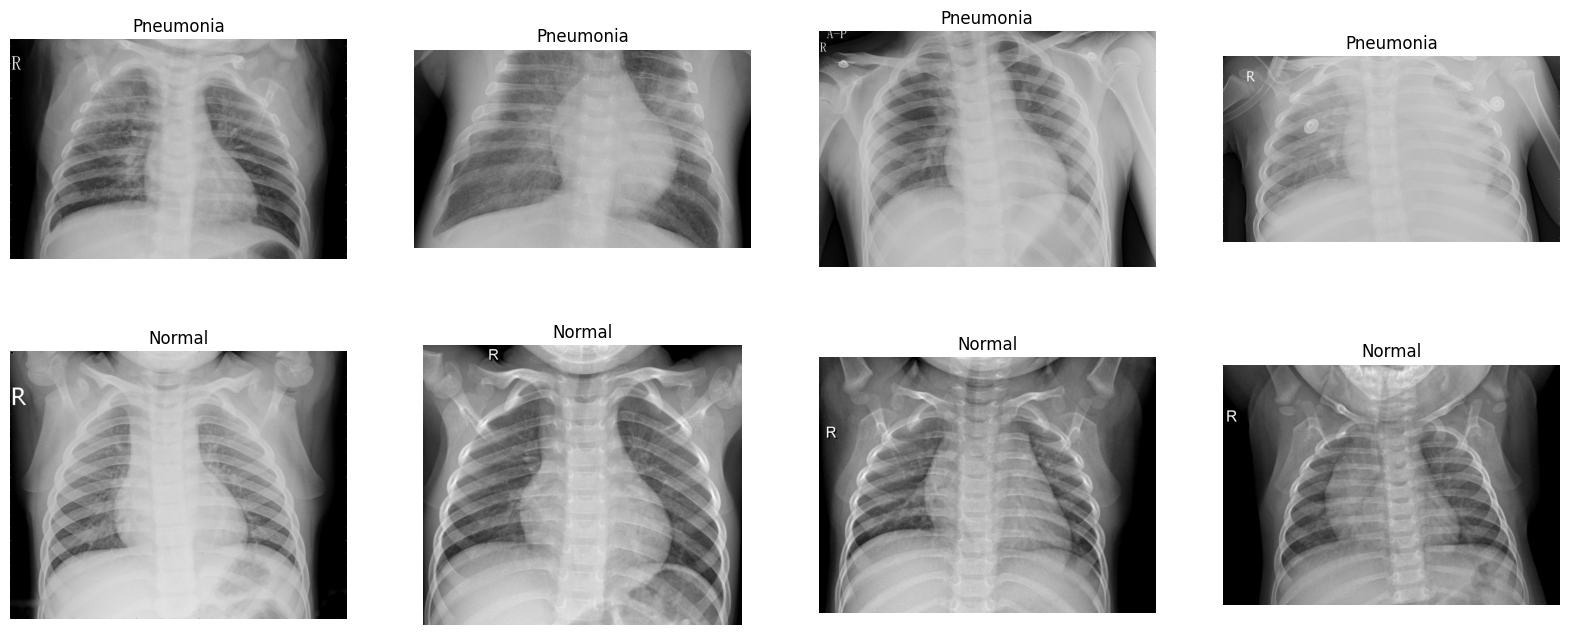

In [ ]:
plt.figure(figsize=(20,8))
for i,img_path in enumerate(train_df[train_df['label'] == 1][0:4]['image']):
    plt.subplot(2,4,i+1)
    plt.axis('off')
    img = plt.imread(img_path)
    plt.imshow(img, cmap='gray')
    plt.title('Pneumonia')
    
for i,img_path in enumerate(train_df[train_df['label'] == 0][0:4]['image']):
    plt.subplot(2,4,4+i+1)
    plt.axis('off')
    img = plt.imread(img_path)
    plt.imshow(img, cmap='gray')
    plt.title('Normal')


In [ ]:
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)
y_val_cat = to_categorical(y_val, num_classes=2)


In [ ]:
model = Sequential()

model.add(Conv2D(filters=8, kernel_size=(7,7), padding='same', activation='relu', input_shape=(196, 196, 1)))
model.add(Conv2D(filters=8, kernel_size=(7,7), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(filters=16, kernel_size=(5,5), padding='same', activation='relu'))
model.add(Conv2D(filters=16, kernel_size=(5,5), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2, activation='softmax'))

'''
optimizer = Adam(lr=0.0001, decay=1e-5)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
'''

model.summary()

optimizer = Adam(learning_rate=0.0001, decay=1e-5)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])


callback = EarlyStopping(monitor='loss', patience=6)
history = model.fit(X_train, y_train_cat, validation_data=(X_test, y_test_cat), batch_size=4, epochs=100, verbose=1, callbacks=[callback], class_weight={0:6.0, 1:0.5})

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_90 (Conv2D)              │ (None, 196, 196, 8)    │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 196, 196, 8)    │         3,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 65, 65, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 65, 65, 16)     │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 65, 65, 16)     │         6,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 21, 21, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 21, 21, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 21, 21, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 5, 5, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,850 (1.41 MB)

 Trainable params: 369,850 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1028/1219 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.3476 - loss: 0.7897

KeyboardInterrupt: 